Ujjivan Small Finance Bank Limited (Ujjivan SFB) is a Bengaluru-based **small finance bank focused on advancing financial inclusion by serving financially unserved and underserved segments** across India. Established in 2005 as Ujjivan Financial Services Ltd., an NBFC founded by Samit Ghosh, the institution received RBI approval to operate as a Small Finance Bank (SFB) in 2016 and commenced banking operations in February 2017. Over the years, Ujjivan SFB has evolved from a predominantly microfinance institution into a diversified banking franchise. While customer relationships often begin through micro banking, they expand into housing finance, MSME lending, vehicle finance, gold loans, agriculture finance, deposits, and other banking products. As of the [Annual Report 2025–26](https://www.ujjivansfb.bank.in/assets/USFB_Annual_Report_FY_2025_26_80ced81881.pdf), the Bank holds a **gross loan book of ₹406 billion**, with secured assets accounting for 49.4% of the portfolio and group loans comprising 36.1%. In April 2026, the Bank received a response from the RBI regarding its application for voluntary transition to a universal bank. Vehicle finance, gold loans, and agri banking have been identified as key growth drivers.

As of the [Q1 FY2026–27 report](https://www.ujjivansfb.bank.in/assets/Ujjivan_SFB_Q1_FY_27_IR_PPT_9a9ad1434e.pdf) (published on 30 June 2026), the Bank operates a **pan-India network of 814 branches across 347 districts in 26 States and Union Territories**. Karnataka, Tamil Nadu, and West Bengal are the top three contributors, together accounting for over 35% of the gross loan book. The Bank serves over 10.2 million customers across metro, urban, semi-urban, and rural markets through a combination of physical, assisted, and digital channels. For FY2026–27, the Bank has outlined its strategic outlook as: <span style="font-family: monospace;">"grow responsibly, deepen individual lending, and continue the graduation of customers into higher-value secured products over time."</span>


> **AGENDA:** Recommend at least 100 candidate district-level locations for Ujjivan Small Finance Bank's next phase of branch expansion, using only free and publicly available data. 
>The output should be a ranked, tiered, and business-justified set of locations. 
>Recommendations must be limited to new districts where Ujjivan does not currently operate.


We should also align with the growth strategy stated in the Annual Report:

<span style="font-family: monospace;">"Our branch expansion this year is not about coverage alone but about strengthening the distribution infrastructure for both assets and liabilities in markets where we already have presence and customer understanding."</span>

- We used the Ujjivan [Branch Locator API](https://www.ujjivansfb.bank.in/api/location?type=branches) to obtain the list of all branches. As of 5 August 2026, the dataset consists of 838 active branches.
- We mapped the latitude–longitude coordinates of the branches to the [Local Government Directory (2024)](https://bharatlas.com/view/lgd_districts) boundaries to identify their corresponding districts. (An alternative approach would be to map branches using the India PIN Code directory.)

In [4]:
%load_ext autoreload 
%autoreload 2
from pathlib import Path
from joblib import dump,load
import numpy as np, pandas as pd
pd.options.mode.copy_on_write = True
import geopandas as gpd
import warnings ; warnings.simplefilter('ignore')
np.random.seed(20260805)
from IPython.display import display



TEMP_DIR = Path.home()/"Projects Running/USFB_temp"
TEMP_DIR.mkdir(exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<class 'pandas.core.frame.DataFrame'>
Index: 838 entries, hzz5vq1afwslkuejsr63ssv4 to fkq2qrfo3lvrhje0h839qy89
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   BranchCode  837 non-null    string 
 1   BranchName  838 non-null    string 
 2   Address     838 non-null    string 
 3   Latitude    838 non-null    float64
 4   Longitude   838 non-null    float64
dtypes: float64(2), string(3)
memory usage: 117.8+ KB
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 785 entries, 0 to 784
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   dtname     785 non-null    category
 1   stname     785 non-null    category
 2   dist_lgd   785 non-null    int32   
 3   state_lgd  785 non-null    int32   
 4   geometry   785 non-null    geometry
dtypes: category(2), geometry(1), int32(2)
memory usage: 38.3 KB

 Match District : 100.00 %


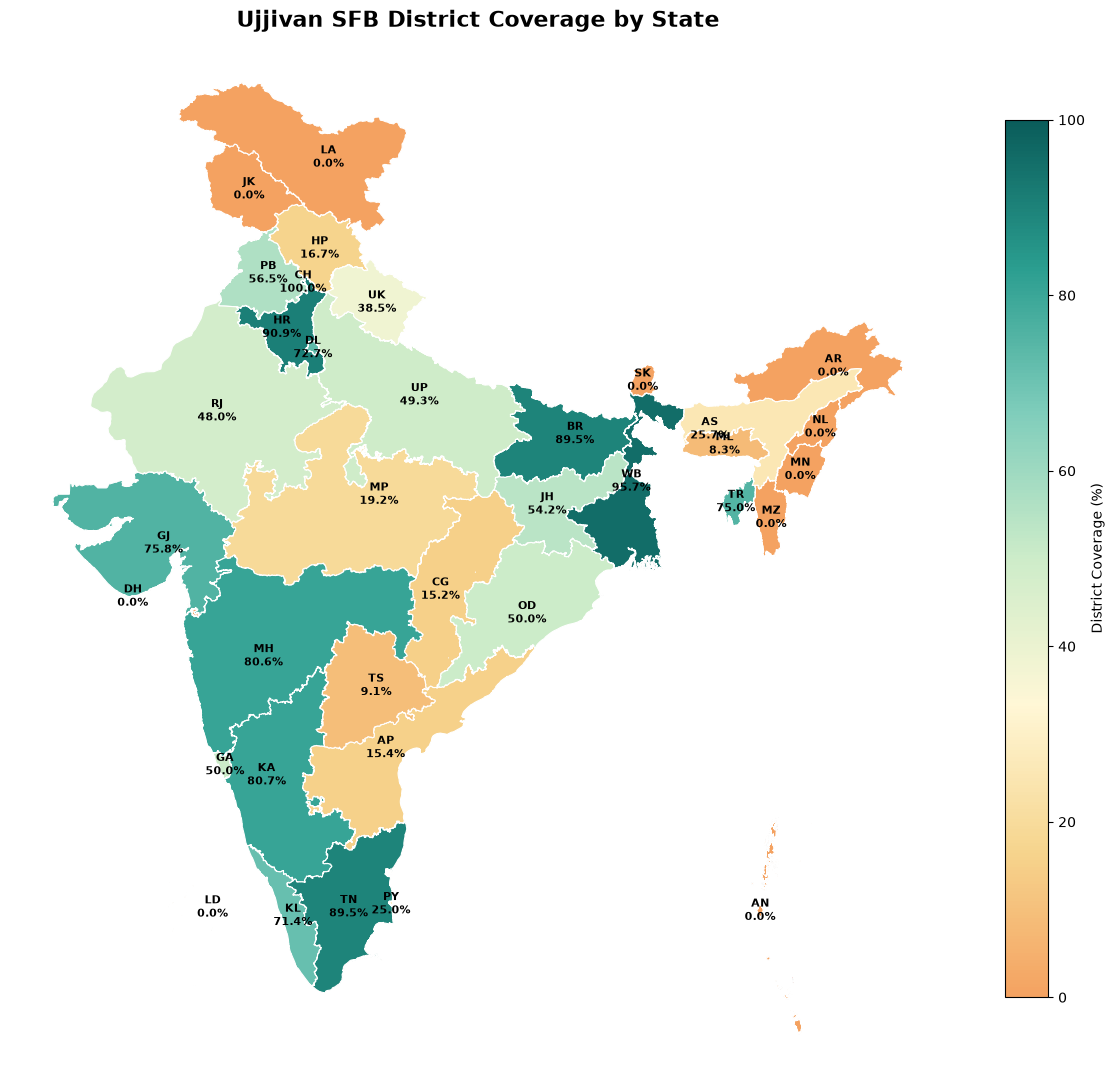

In [5]:
## == BRANCH LOCATOR ====
BASE = pd.read_csv(
    next(Path("./data/branch locator api").glob("*.csv")),
    header=0, index_col="DocumentID", 
    usecols=["DocumentID","BranchCode","BranchName","Address","Latitude","Longitude"],
    dtype={
        "BranchCode": 'string[pyarrow]',
        "BranchName": 'string[pyarrow]',
        "Address": 'string[pyarrow]',
        "Latitude": 'float64',
        "Longitude": 'float64',
    }
)
for col in ["BranchCode","BranchName","Address"] :
    BASE[col] = BASE[col].str.lower().str.strip()
BASE.info()
## ======

## == ADMINISTRATIVE BOUNDARIES ====
ADM = gpd.read_file(
    next(Path("./data/lgd").glob("*.geojson")),
    columns=[
        "dtname","stname","dist_lgd","state_lgd",
        "geometry",
    ],
)
ADM["dtname"] = ADM["dtname"].str.strip().str.title().astype('category')
ADM["stname"] = ADM["stname"].str.strip().str.upper().astype('category')
ADM.info()
## ======


## == Spatial Join ====
BRANCH_MASTER = gpd.sjoin(
    gpd.GeoDataFrame(
        BASE,
        geometry=gpd.points_from_xy(
            BASE["Longitude"],BASE["Latitude"],
            crs='EPSG:4326',
        ),
    ),
    ADM,
    how='left',
    predicate='within',
).drop(columns=["index_right","geometry",])

assert BRANCH_MASTER["dtname"].notna().all(), "Some branches could not be mapped to a district."
print(f"""\n Match District : {BRANCH_MASTER["dtname"].notna().mean() * 100:.2f} %""")
BRANCH_MASTER.to_parquet(TEMP_DIR/'BRANCH_MASTER.parquet',index=True,compression='zstd')

COVERAGE = (
    ADM
    .groupby("stname", observed=True, sort=False)
    .agg(
        Total_Districts=("dtname", 'nunique')
    )
    .join(
        BRANCH_MASTER
        .groupby("stname", observed=True, sort=False)
        .agg(
            Covered_Districts=("dtname", 'nunique'),
            Existing_Branches=("BranchName", 'count'),
        ),
        how='left',
        sort=False,
    )
    .fillna(0)
    .astype({
        "Total_Districts": 'int32',
        "Covered_Districts": 'int32',
        "Existing_Branches": 'int32',
    })
)
COVERAGE.to_parquet(TEMP_DIR/'COVERAGE.parquet',index=True,compression='zstd')

## ======


## -- PLOTTING ----
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt


STATE_ABBR = {
    "ANDAMAN & NICOBAR": "AN",
    "ANDHRA PRADESH": "AP",
    "ARUNACHAL PRADESH": "AR",
    "ASSAM": "AS",
    "BIHAR": "BR",
    "CHANDIGARH": "CH",
    "CHHATTISGARH": "CG",
    "DADRA,NAGAR HAVELI,DAMAN & DIU": "DH",
    "DELHI": "DL",
    "GOA": "GA",
    "GUJARAT": "GJ",
    "HARYANA": "HR",
    "HIMACHAL PRADESH": "HP",
    "JAMMU & KASHMIR": "JK",
    "JHARKHAND": "JH",
    "KARNATAKA": "KA",
    "KERALA": "KL",
    "LADAKH": "LA",
    "LAKSHADWEEP": "LD",
    "MADHYA PRADESH": "MP",
    "MAHARASHTRA": "MH",
    "MANIPUR": "MN",
    "MEGHALAYA": "ML",
    "MIZORAM": "MZ",
    "NAGALAND": "NL",
    "ODISHA": "OD",
    "PUDUCHERRY": "PY",
    "PUNJAB": "PB",
    "RAJASTHAN": "RJ",
    "SIKKIM": "SK",
    "TAMIL NADU": "TN",
    "TELANGANA": "TS",
    "TRIPURA": "TR",
    "UTTAR PRADESH": "UP",
    "UTTARAKHAND": "UK",
    "WEST BENGAL": "WB",
} # ref: https://en.wikipedia.org/wiki/ISO_3166-2:IN
dump(STATE_ABBR,TEMP_DIR/'STATE_ABBR.joblib')


STATE_MAP = (
    ADM
    .dissolve(by="stname", observed=True)
    .join(COVERAGE)
)
STATE_MAP["Districts_Coverage"] = (100 * STATE_MAP["Covered_Districts"]/STATE_MAP["Total_Districts"]).round(2)

fig, ax = plt.subplots(figsize=(12, 12))

STATE_MAP.plot(
    column="Districts_Coverage",
    cmap=LinearSegmentedColormap.from_list(
        "ujjivan",
        [
            "#F4A261",  
            "#F6D58E",  
            "#FFF7D6",  
            "#CDECC9",  
            "#7FCDBB",  
            "#2A9D8F",  
            "#0A5C5A",  
        ],
    ),
    edgecolor="white",
    linewidth=0.8,
    legend=True,
    legend_kwds={
        "label": "District Coverage (%)",
        "shrink": 0.75,
    },
    ax=ax,
)

for state, row in STATE_MAP.iterrows():
    x, y = row.geometry.representative_point().coords[0]

    ax.text(
        x,
        y,
        f"{STATE_ABBR.get(state, state)}\n{row['Districts_Coverage']:.1f}%",
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        color="black",
    )

ax.set_title(
    "Ujjivan SFB District Coverage by State",
    fontsize=16,
    fontweight="bold",
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

## ------

Based on the background, we shortlist **Madhya Pradesh**, **Chhattisgarh**, and **Andhra Pradesh** for further analysis. These states have 15–20% district penetration, providing a balance between expansion opportunities and an existing market presence. Additionally, all three are bordered by states with relatively high penetration, offering potential operational synergies and network expansion. (Although Andhra Pradesh was the epicentre of the 2010 microfinance crisis, subsequent RBI-led regulatory reforms have largely normalized the operating environment. Today, microfinance lending is governed under a uniform national regulatory framework emphasizing responsible lending, borrower protection, household repayment assessment, and credit discipline. Consequently, the historical crisis alone is not considered a constraint in shortlisting Andhra Pradesh for further analysis.)

In [ ]:
states_chosen = ["MADHYA PRADESH","CHHATTISGARH","ANDHRA PRADESH"]
COVERAGE.loc[states_chosen].sort_values("Existing_Branches")

,Total_Districts,Covered_Districts,Existing_Branches
stname,,,
ANDHRA PRADESH,26,4,4
CHHATTISGARH,33,5,5
MADHYA PRADESH,52,10,15
